# Resonator IQ geometry and frequency/dissipation conversion

This notebook develops the mathematics behind the resonator conversion tools in `souk_readout_tools.resonator`. It follows the fitted model used by `souk_readout_tools.fitting`, while separating four ideas that are easy to conflate:

1. the raw measured IQ loop;
2. removal of the readout-chain envelope (deembedding);
3. translation and rotation of the resonance circle (phase centering);
4. conversion of IQ motion into frequency and loss coordinates.

The local linearized method and the fitted Mobius method are both derived. The Mobius section treats symmetric, asymmetric, and Duffing-nonlinear resonators separately.

Each mathematical section also includes a **Codebase path** callout. These distinguish the transparent low-level helpers used to build the figures from the higher-level package entry points normally used with parsed sweeps and timestream samples.

> **API note.** The low-level fitted `ResonatorCalibration.convert_raw_iq()` methods return probe detuning relative to the fitted resonance: $f_{\rm probe}-f_r$. Positive values place the probe above resonance. With its default `method='mobius'`, the second result is the matched-scale dissipation quadrature $q_d=\Delta(1/2Q_i)$. The diagnostic `method='circle'` path keeps the probe-side sign convention for its effective circle-frequency coordinate and instead returns the explicitly defined radial proxy $\rho=|z_c|/R-1$: the signed fractional change in radius relative to the nominal centered circle. Resonator detuning relative to a fixed probe is $f_r-f_{\rm probe}$, with the opposite sign. The exact Mobius loss coordinate and the local normalization of $\rho$ are derived below.

## 1. Notation and coordinate frames

Write a complex readout sample as

$$
z = I + jQ.
$$

For a tone at frequency $f$, define the fractional probe detuning

$$
x = \frac{f-f_r}{f_r},
$$

where $f_r$ is the fitted resonance frequency. The code uses $j=\sqrt{-1}$ in the equations below.

| Symbol | Meaning |
|---|---|
| $z_{\rm raw}$ | measured IQ after the cables and readout electronics |
| $z$ | deembedded resonator-plane transmission |
| $z_c$ | phase-centered IQ: translated to the circle center and rotated |
| $Q_i$ | internal quality factor |
| $Q_e$ | complex coupling quality factor |
| $Q_l$ | loaded quality factor |
| $R$ | radius of the phase-centered resonance circle |
| $\delta\gamma$ | change in internal inverse quality factor, $\Delta(1/Q_i)$ |
| $d$ | physical internal-loss coordinate, $d=\Delta(1/2Q_i)=\delta\gamma/2$ |

There are two frequency-shift sign conventions worth naming explicitly:

- a **probe detuning** is $(f_{\rm probe}-f_r)/f_r$;
- for a fixed probe tone, a detector-driven resonance shift $\Delta f_r/f_r$ moves the probe detuning by the opposite sign.

The fitted Mobius converter reports probe detuning relative to its fitted reference. The historical local timestream converter is arranged to report detector resonance motion for a fixed probe.

> **Codebase path: choose the coordinate for the task.** `ResonatorCalibration.convert_raw_iq()` and `modulation.demodulate(..., calibration=...)` retain absolute probe detuning because tracking needs to know where the applied tone sits relative to the fitted resonance. `noise.fractional_frequency_and_dissipation_timestreams()` instead interpolates a sweep reference at the fixed probe tone, calls `ResonatorCalibration.convert_referenced_raw_iq()`, and returns reference-subtracted resonator motion for detector-noise plots.

In [9]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('..') if Path('../src').is_dir() else Path('.')
DOC = Path('.') if Path('resonator_math_derivations.ipynb').exists() else Path('doc')
sys.path.insert(0, str((ROOT / 'src').resolve()))

from souk_readout_tools import fitting, resonator

OUT = DOC / 'resonator_math'
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'legend.fontsize': 8,
    'svg.hashsalt': 'souk-resonator-math',
})

def savefig(fig, name):
    fig.tight_layout()
    fig.savefig(OUT / f'{name}.svg', metadata={'Date': None})
    return fig

def coupling_q(Qc, phi):
    return Qc * (1.0 + 1j * np.tan(phi))

def loaded_q(Qi, Qc, phi):
    return 1.0 / (1.0 / Qi + np.real(1.0 / coupling_q(Qc, phi)))

# Written explicitly here so the plotted derivation can be read line by line.
# Production conversion uses resonator.mobius_coordinate().
def mobius_coordinate(z_centered, radius, Ql):
    return -1j * (radius - z_centered) / (2.0 * Ql * (radius + z_centered))

# Mirror the fitted-calibration runtime stages on controlled synthetic data.
def model_frames(f, fr, Qi, Qc, phi, gain=1.2, gain_phase=0.65, tau=32e-9, anl=0.0):
    raw = fitting.s21_model(f, fr, Qi, Qc, phi, gain, gain_phase, tau, anl=anl)
    deembedded = resonator.model_deembed(f, raw, gain, gain_phase, tau)
    Qe = coupling_q(Qc, phi)
    Ql = loaded_q(Qi, Qc, phi)
    phase_center = resonator.model_phase_center_geometry(Ql, Qe)
    centered = phase_center.apply(deembedded)
    return raw, deembedded, centered, phase_center, Ql

FR = 2.0e9
QI = 1.0e5
QC = 5.0e4
PHI_ASYM = 0.5
QL_SYM = loaded_q(QI, QC, 0.0)
linewidth_axis = np.linspace(-10.0, 10.0, 1001)
F = FR + linewidth_axis * FR / QL_SYM


## 2. The IQ loop

The linear fitted model is

$$
z_{\rm raw}(f) = E(f)\left[1-\frac{1/Q_e}{1/Q_i+1/Q_e+2jx}\right],
$$

with a readout-chain envelope

$$
E(f)=a\,e^{j\alpha}e^{-j2\pi f\tau}.
$$

The term in square brackets is the resonator-plane transmission. A frequency sweep traces a circle in the complex plane. The envelope scales and rotates that circle; cable delay adds a frequency-dependent rotation, which can visibly wind or shear a wide raw sweep. A complex $Q_e$ changes the circle geometry and shifts the relation between the fitted $f_r$ and the most visually symmetric point on the circle.

> **Codebase path: real sweep input.** Hardware sweep payloads are first normalized with `client.parse_sweep_data(client.get_sweep_data())`. The parsed dictionary stores one trace per tone in `sweep_f`, `sweep_i`, and `sweep_q`. For a fitted calibration, pass that dictionary to `fitting.batch_fit()` and construct `ResonatorCalibration.from_fit(fit)` for each successful tone. For a model-light empirical calibration, select one complex trace and call `ResonatorCalibration.from_sweep(sweep_f, sweep_z)`. The figure below uses `fitting.s21_model()` only to generate controlled synthetic IQ loops.

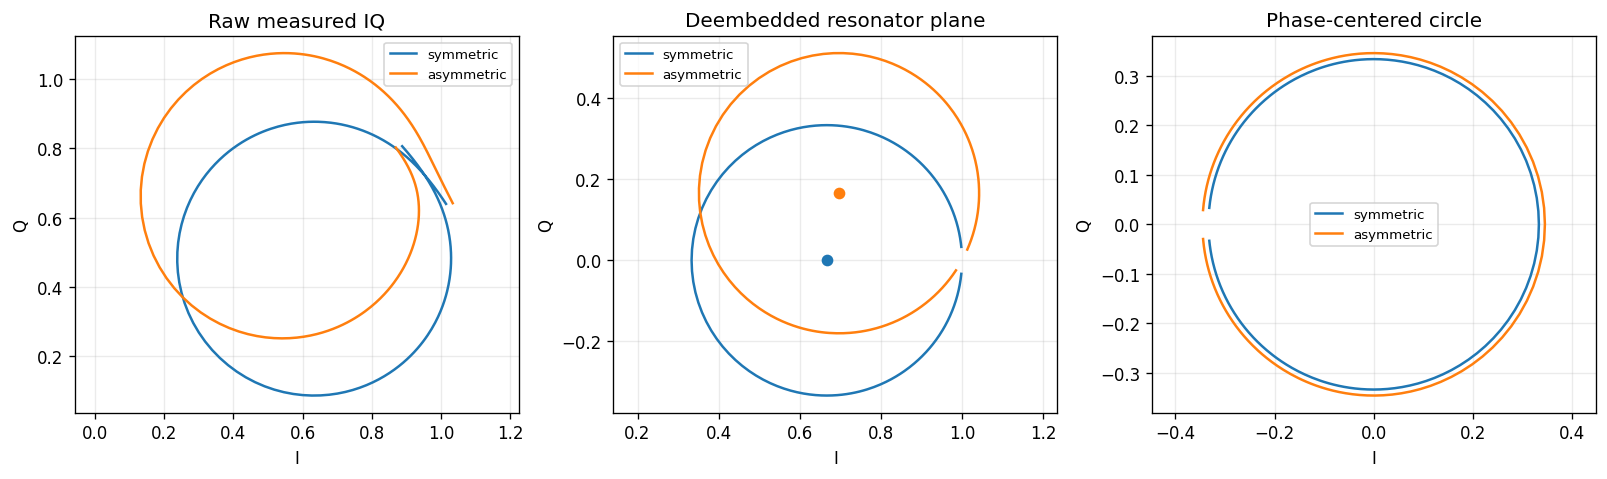

In [10]:
raw_s, de_s, cen_s, pc_s, ql_s = model_frames(F, FR, QI, QC, 0.0)
raw_a, de_a, cen_a, pc_a, ql_a = model_frames(F, FR, QI, QC, PHI_ASYM)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.1))
for z, label in [(raw_s, 'symmetric'), (raw_a, 'asymmetric')]:
    axes[0].plot(z.real, z.imag, label=label)
for z, label in [(de_s, 'symmetric'), (de_a, 'asymmetric')]:
    axes[1].plot(z.real, z.imag, label=label)
for z, label in [(cen_s, 'symmetric'), (cen_a, 'asymmetric')]:
    axes[2].plot(z.real, z.imag, label=label)

for ax, title in zip(axes, ['Raw measured IQ', 'Deembedded resonator plane', 'Phase-centered circle']):
    ax.set_title(title)
    ax.set_xlabel('I')
    ax.set_ylabel('Q')
    ax.set_aspect('equal', adjustable='datalim')
    ax.legend()
axes[1].plot([pc_s.center.real], [pc_s.center.imag], 'o', color='C0')
axes[1].plot([pc_a.center.real], [pc_a.center.imag], 'o', color='C1')
savefig(fig, '01_iq_coordinate_frames')
plt.show()


![Raw, deembedded, and centered IQ loops](resonator_math/01_iq_coordinate_frames.svg)

## 3. Deembedding the readout-chain envelope

For a scalar cable delay, deembedding multiplies by the inverse envelope:

$$
z(f)=z_{\rm raw}(f)\,\frac{e^{+j2\pi f\tau}e^{-j\alpha}}{a}.
$$

The generic sweep helper does not assume a fitted scalar gain. It first removes delay, estimates an off-resonance complex baseline $b$ from the sweep edges, and divides by that baseline:

$$
z(f)=\frac{z_{\rm raw}(f)e^{+j2\pi f\tau}}{b}.
$$

For a frequency-dependent group delay $\tau_g(f)$, phase is obtained by integration rather than by multiplying the local value by frequency:

$$
\phi_{\rm corr}(f)=2\pi\int_{f_{\rm ref}}^f \tau_g(f')\,df',
\qquad
z(f)=z_{\rm raw}(f)e^{j\phi_{\rm corr}(f)}/b.
$$

The shared reference frequency matters when sweep-derived parameters are reused on a fixed-tone timestream. The fixed-tone correction must preserve the same phase reference as the sweep.

> **Codebase path: two deembedding routes.** The empirical route is `deembed()`: remove a scalar cable delay with `remove_cable_delay()` or an integrated calibration with `remove_group_delay()`, estimate the complex off-resonance edge baseline, and divide by it. `ResonatorCalibration.from_sweep()` uses this route. The fitted route stores the gain, gain phase, and delay from the resonance fit. At runtime, `ResonatorCalibration.transform_raw_iq()` calls `deembed_raw_iq()`, which delegates to `DeembeddingCalibration.apply()`. The figure below spells out the fitted scalar-envelope operations explicitly so their geometric effect is visible.

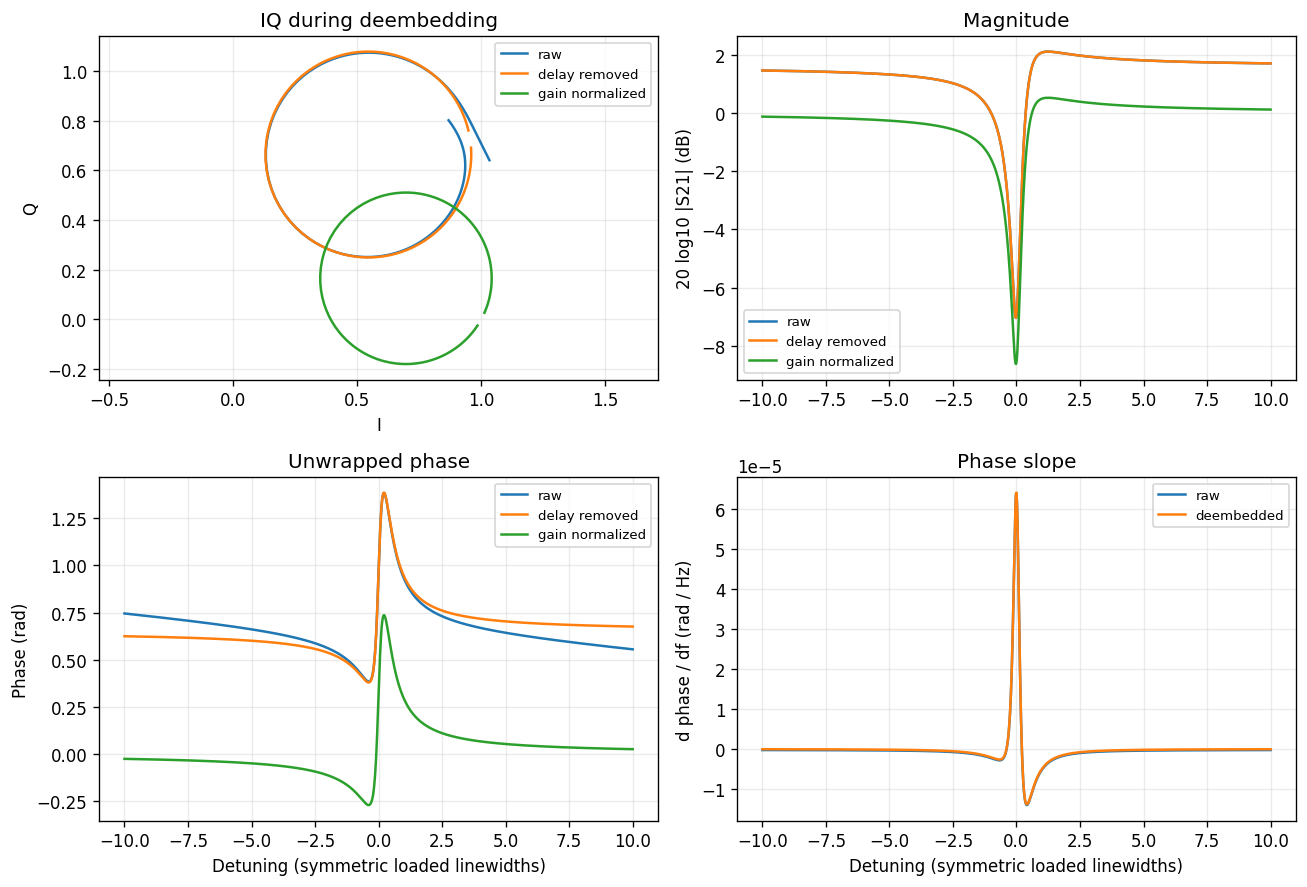

In [11]:
gain, gain_phase, tau = 1.2, 0.65, 32e-9
z_no_delay = raw_a * np.exp(2j * np.pi * F * tau)
z_deembedded = z_no_delay * np.exp(-1j * gain_phase) / gain

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
axes[0, 0].plot(raw_a.real, raw_a.imag, label='raw')
axes[0, 0].plot(z_no_delay.real, z_no_delay.imag, label='delay removed')
axes[0, 0].plot(z_deembedded.real, z_deembedded.imag, label='gain normalized')
axes[0, 0].set_title('IQ during deembedding')
axes[0, 0].set_xlabel('I')
axes[0, 0].set_ylabel('Q')
axes[0, 0].set_aspect('equal', adjustable='datalim')
axes[0, 0].legend()

for z, label in [(raw_a, 'raw'), (z_no_delay, 'delay removed'), (z_deembedded, 'gain normalized')]:
    axes[0, 1].plot(linewidth_axis, 20 * np.log10(np.abs(z)), label=label)
    axes[1, 0].plot(linewidth_axis, np.unwrap(np.angle(z)), label=label)
axes[0, 1].set_title('Magnitude')
axes[0, 1].set_ylabel('20 log10 |S21| (dB)')
axes[1, 0].set_title('Unwrapped phase')
axes[1, 0].set_ylabel('Phase (rad)')
axes[1, 0].set_xlabel('Detuning (symmetric loaded linewidths)')
axes[0, 1].legend()
axes[1, 0].legend()

phase_raw = np.unwrap(np.angle(raw_a))
phase_de = np.unwrap(np.angle(z_deembedded))
axes[1, 1].plot(linewidth_axis, np.gradient(phase_raw, F), label='raw')
axes[1, 1].plot(linewidth_axis, np.gradient(phase_de, F), label='deembedded')
axes[1, 1].set_title('Phase slope')
axes[1, 1].set_xlabel('Detuning (symmetric loaded linewidths)')
axes[1, 1].set_ylabel('d phase / df (rad / Hz)')
axes[1, 1].legend()
savefig(fig, '02_deembedding_stages')
plt.show()


![Deembedding stages](resonator_math/02_deembedding_stages.svg)

## 4. Phase centering

Define

$$
g=\frac{1}{Q_e},
\qquad
\gamma=\frac{1}{Q_i}+\operatorname{Re}(g)=\frac{1}{Q_l},
\qquad
\beta=\operatorname{Im}(g).
$$

Then the deembedded linear resonator can be written

$$
z=1-\frac{g}{\gamma+j(\beta+2x)}.
$$

Introduce the shifted circle coordinate

$$
u=x+\frac{\beta}{2}.
$$

The exact circle center and radius are

$$
C=1-\frac{Q_l}{2Q_e},
\qquad
R=\left|\frac{Q_l}{2Q_e}\right|.
$$

Let $A=1-C=Q_l/(2Q_e)$. After subtracting $C$ and rotating by

$$
\theta=\pi-\arg(A),
$$

the centered coordinate is

$$
z_c=(z-C)e^{j\theta}
=R\frac{1-2jQ_lu}{1+2jQ_lu}.
$$

The asymmetric loop is still a circle. Asymmetry shifts the circle coordinate by $\beta/2$; it does not prevent an exact inversion.

> **Codebase path: empirical and fitted centering.** The empirical helper `phase_center()` fits a Kasa circle with `center_circle()`, subtracts its center, and rotates the edge-derived off-resonance point onto the negative real axis with `rotate_to_real_axis()`. `ResonatorCalibration.from_sweep()` stores those empirical parameters. `ResonatorCalibration.from_fit()` instead uses model-consistent deembedded center, radius, and rotation values from the fit; `model_phase_center_geometry()` exposes the same exact notch-model geometry. Runtime samples pass through `phase_center_iq()` after deembedding.

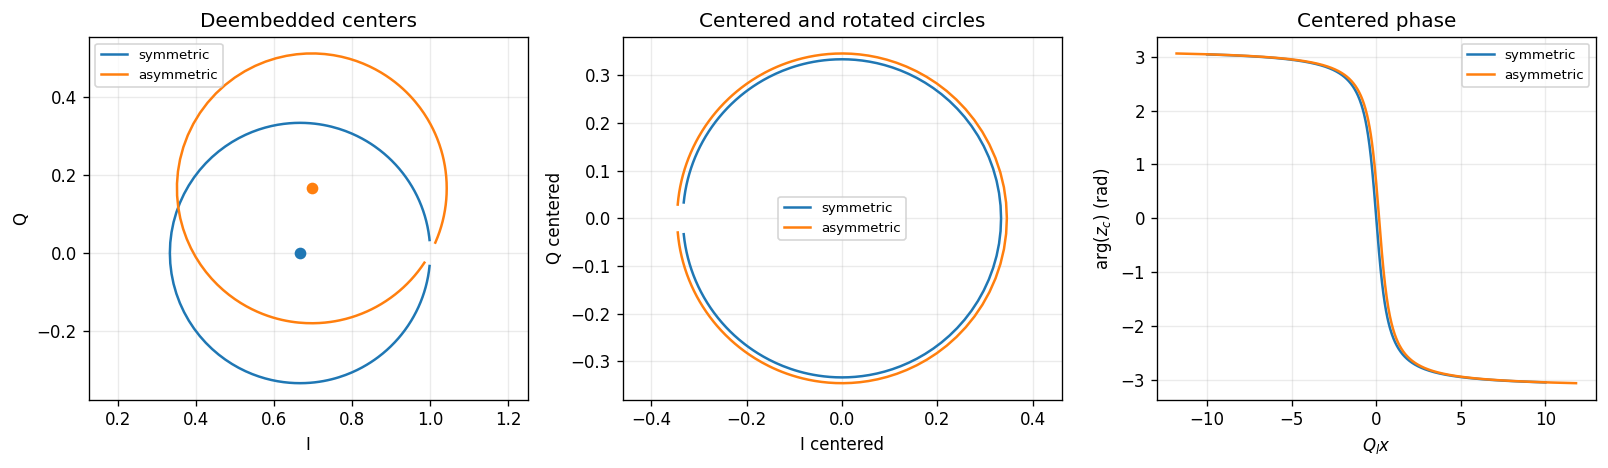

In [12]:
phase_s = np.unwrap(np.angle(cen_s))
phase_a = np.unwrap(np.angle(cen_a))
x = (F - FR) / FR

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))
axes[0].plot(de_s.real, de_s.imag, label='symmetric')
axes[0].plot(de_a.real, de_a.imag, label='asymmetric')
axes[0].plot(pc_s.center.real, pc_s.center.imag, 'o', color='C0')
axes[0].plot(pc_a.center.real, pc_a.center.imag, 'o', color='C1')
axes[0].set_title('Deembedded centers')
axes[0].set_xlabel('I')
axes[0].set_ylabel('Q')
axes[0].set_aspect('equal', adjustable='datalim')

axes[1].plot(cen_s.real, cen_s.imag, label='symmetric')
axes[1].plot(cen_a.real, cen_a.imag, label='asymmetric')
axes[1].set_title('Centered and rotated circles')
axes[1].set_xlabel('I centered')
axes[1].set_ylabel('Q centered')
axes[1].set_aspect('equal', adjustable='datalim')

axes[2].plot(x * ql_s, phase_s, label='symmetric')
axes[2].plot(x * ql_a, phase_a, label='asymmetric')
axes[2].set_title('Centered phase')
axes[2].set_xlabel('$Q_l x$')
axes[2].set_ylabel('arg($z_c$) (rad)')
for ax in axes:
    ax.legend()
savefig(fig, '03_phase_centering')
plt.show()


![Phase centering](resonator_math/03_phase_centering.svg)

## 5. IQ to magnitude and phase

For any coordinate frame, conversion from Cartesian IQ to polar magnitude and phase is

$$
|z|=\sqrt{I^2+Q^2},
\qquad
\phi=\operatorname{atan2}(Q,I).
$$

Magnitude is commonly plotted as

$$
20\log_{10}|z|.
$$

If $I$ and $Q$ have independent standard uncertainties $\sigma_I$ and $\sigma_Q$, first-order propagation gives

$$
\sigma_{|z|}^2=
\left(\frac{I}{|z|}\sigma_I\right)^2+
\left(\frac{Q}{|z|}\sigma_Q\right)^2,
$$

$$
\sigma_{\phi}^2=
\left(\frac{-Q}{|z|^2}\sigma_I\right)^2+
\left(\frac{I}{|z|^2}\sigma_Q\right)^2.
$$

The phase is only meaningful relative to a chosen origin. Raw phase includes cable delay and an off-origin loop. Phase-centered phase is the angle around the resonance circle and is usually the cleaner tracking observable.

> **Codebase path: plotting versus conversion.** Magnitude/phase plotting is an ordinary polar view of whichever IQ frame was selected. For a calibrated centered circle, `ResonatorCalibration.to_phase_amplitude()` returns `angle(z_centered)` and `abs(z_centered) / radius`. That normalized amplitude is a radial diagnostic; it is not the matched dissipation coordinate $\Delta(1/2Q_i)$.

## 6. Local linearized IQ to frequency/dissipation conversion

The historical small-signal converter uses a sweep-derived tangent at a fixed probe frequency $f_p$. Let

$$
z_0=z(f_p),
\qquad
G=\left.\frac{dz}{df}\right|_{f_p}.
$$

For a timestream sample $z_t$, define the displacement with the package sign convention

$$
\Delta z=z_0-z_t.
$$

Projecting onto the tangent $G$ and its $+90^\circ$ rotation $jG$ gives

$$
\Delta f_{\rm lin}=
\frac{\operatorname{Re}(\Delta z)\operatorname{Re}(G)+
\operatorname{Im}(\Delta z)\operatorname{Im}(G)}{|G|^2},
$$

$$
\Delta d_{\rm lin,Hz}=
\frac{\operatorname{Im}(\Delta z)\operatorname{Re}(G)-
\operatorname{Re}(\Delta z)\operatorname{Im}(G)}{|G|^2}.
$$

The returned fractional quadratures are

$$
\frac{\Delta f_{\rm lin}}{f_p},
\qquad
\frac{\Delta d_{\rm lin,Hz}}{f_p}.
$$

For the symmetric linear notch model, a small detector resonance shift gives the first value $\Delta f_r/f_p$, while a small internal-loss change gives the second value

$$
\Delta d_{\rm lin,Hz}/f_p=\Delta\left(\frac{1}{2Q_i}\right).
$$

The device-physics quantity of interest is usually the dimensionless inverse-internal-Q change

$$
\delta_i=\Delta\left(\frac{1}{Q_i}\right).
$$

For direct comparison with fractional-frequency noise it is convenient to plot the half-scaled dissipation quadrature

$$
q_d=\frac{\delta_i}{2}=\Delta\left(\frac{1}{2Q_i}\right).
$$

This is the convention used by the historical converter. It puts frequency and dissipation on matched dimensionless axes: locally isotropic amplifier IQ noise appears at the same level in both spectra, while detector resonance noise is commonly much larger in the frequency quadrature. To convert a $q_d$ amplitude spectral density back to the $\Delta(1/Q_i)$ convention, multiply by two; for a power spectral density, multiply by four.

This projection is local: curvature, large excursions, cable-delay slope, and an off-origin raw loop all limit its accuracy.

> **Codebase path: historical compatibility.** `linearized_frequency_and_dissipation()` constructs a `LinearizedResonatorCalibration.from_sweep()` at the fixed probe frequency. That object optionally smooths the sweep, interpolates $z_0$ and $G=dz/df$, and projects each raw IQ sample with `LinearizedResonatorCalibration.convert_raw_iq()`. It does not deembed or fit a resonator model. The high-level `noise.fractional_frequency_and_dissipation_timestreams(..., method='linearized')` wrapper uses this path so older analyses remain directly comparable.

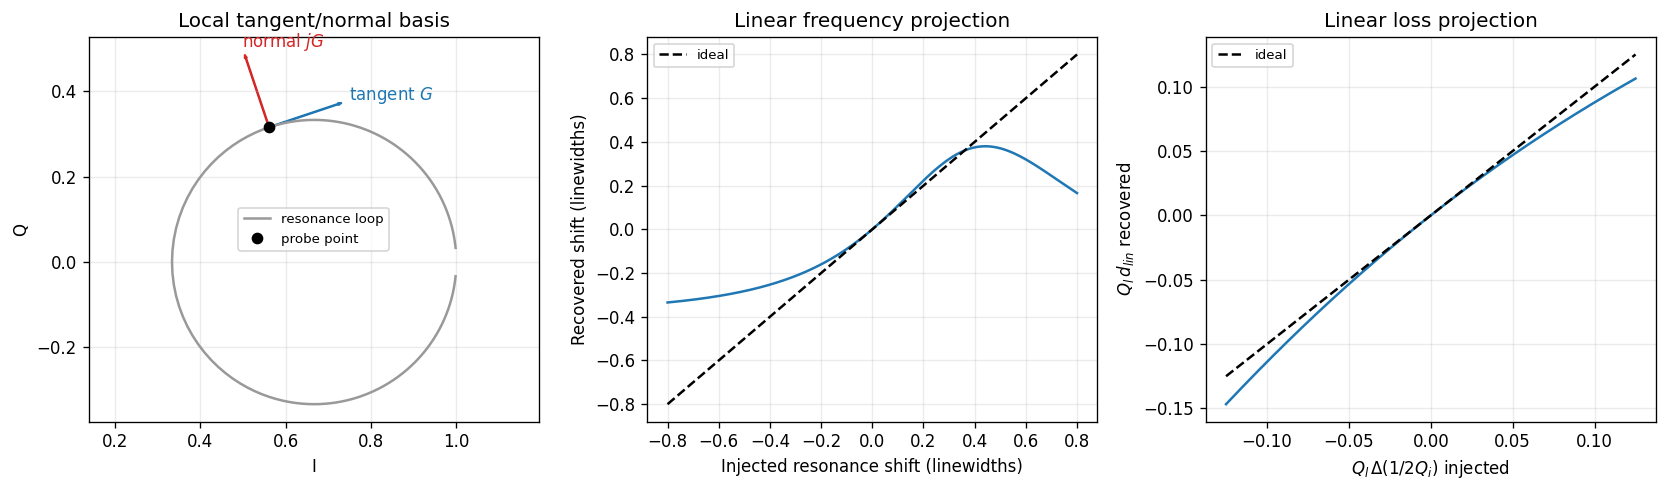

In [13]:
probe_index = np.argmin(np.abs(linewidth_axis - 0.35))
probe = de_s[probe_index]
gradient = np.gradient(de_s, F)[probe_index]
axis_scale = 0.18 / abs(gradient)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
axes[0].plot(de_s.real, de_s.imag, color='0.6', label='resonance loop')
axes[0].plot(probe.real, probe.imag, 'ko', label='probe point')
axes[0].arrow(probe.real, probe.imag, (gradient * axis_scale).real,
              (gradient * axis_scale).imag, width=0.002, color='C0', length_includes_head=True)
axes[0].arrow(probe.real, probe.imag, (1j * gradient * axis_scale).real,
              (1j * gradient * axis_scale).imag, width=0.002, color='C3', length_includes_head=True)
tangent_label = probe + gradient * axis_scale * 1.1
normal_label = probe + 1j * gradient * axis_scale * 1.1
axes[0].text(tangent_label.real, tangent_label.imag, 'tangent $G$', color='C0')
axes[0].text(normal_label.real, normal_label.imag, 'normal $jG$', color='C3')
axes[0].set_title('Local tangent/normal basis')
axes[0].set_xlabel('I')
axes[0].set_ylabel('Q')
axes[0].set_aspect('equal', adjustable='datalim')
axes[0].legend()

probe_frequency = F[probe_index]
detector_shift_hz = np.linspace(-0.8, 0.8, 301) * FR / ql_s
z_reference = fitting.s21_model(probe_frequency, FR, QI, QC, 0.0, 1.0, 0.0, 0.0)
z_shifted = np.array([
    fitting.s21_model(probe_frequency, FR + shift, QI, QC, 0.0, 1.0, 0.0, 0.0)
    for shift in detector_shift_hz
])
cal_linear = resonator.LinearizedResonatorCalibration.from_sweep(F, de_s, probe_frequency, smooth_window_hz=None)
df_fraction, _ = cal_linear.convert_raw_iq(z_shifted)
axes[1].plot(detector_shift_hz / (FR / ql_s), df_fraction * probe_frequency / (FR / ql_s))
axes[1].plot([-0.8, 0.8], [-0.8, 0.8], 'k--', label='ideal')
axes[1].set_title('Linear frequency projection')
axes[1].set_xlabel('Injected resonance shift (linewidths)')
axes[1].set_ylabel('Recovered shift (linewidths)')
axes[1].legend()

loss = np.linspace(-0.25, 0.25, 301) / ql_s
z_loss = np.array([
    fitting.s21_model(probe_frequency, FR, 1.0 / (1.0 / QI + delta_gamma), QC, 0.0, 1.0, 0.0, 0.0)
    for delta_gamma in loss
])
_, dd_fraction = cal_linear.convert_raw_iq(z_loss)
axes[2].plot(loss * ql_s / 2.0, dd_fraction * ql_s)
axes[2].plot([-0.125, 0.125], [-0.125, 0.125], 'k--', label='ideal')
axes[2].set_title('Linear loss projection')
axes[2].set_xlabel('$Q_l\\,\\Delta(1/2Q_i)$ injected')
axes[2].set_ylabel('$Q_l\\,d_{lin}$ recovered')
axes[2].legend()
savefig(fig, '04_linear_tangent_normal')
plt.show()


![Local tangent and normal conversion](resonator_math/04_linear_tangent_normal.svg)

## 7. Exact Mobius inversion: symmetric and asymmetric linear models

The circle relation can be inverted exactly. Define the complex Mobius coordinate

$$
M(z_c)=-\frac{j}{2Q_l}\frac{R-z_c}{R+z_c}.
$$

### 7.1 Symmetric resonator

For a symmetric resonator, $Q_e$ is real and $\beta=0$. Allow an internal-loss perturbation $\delta\gamma=\Delta(1/Q_i)$. The phase-centered model becomes

$$
z_c=R\frac{1-Q_l\delta\gamma-2jQ_lx}
{1+Q_l\delta\gamma+2jQ_lx}.
$$

Substituting this expression into $M$ gives

$$
M=x-j\frac{\delta\gamma}{2}=x-jd.
$$

Therefore the exact linear coordinates are

$$
x=\operatorname{Re}(M),
\qquad
d=\Delta\left(\frac{1}{2Q_i}\right)=-\operatorname{Im}(M).
$$

### 7.2 Asymmetric resonator

For complex $Q_e$, recall $u=x+\beta/2$ with $\beta=\operatorname{Im}(1/Q_e)$. The same derivation gives

$$
M=u-jd=x+\frac{\beta}{2}-jd.
$$

Thus the asymmetry correction is a constant real offset:

$$
x=\operatorname{Re}(M)-\frac{1}{2}\operatorname{Im}\left(\frac{1}{Q_e}\right),
\qquad
d=-\operatorname{Im}(M).
$$

The code stores the real origin correction as `frequency_origin_fraction`.

### 7.3 A well-defined radial loss proxy

The diagnostic `convert_centered_iq(..., method='circle')` path returns

$$
\rho=\frac{|z_c|}{R}-1
$$

as its second value. Using the perturbed linear model,

$$
\rho=
\sqrt{\frac{(1-2Q_ld)^2+(2Q_lu)^2}
{(1+2Q_ld)^2+(2Q_lu)^2}}-1.
$$

This is a well-defined signed fractional radius change: $\rho=0$ on the nominal circle, $\rho>0$ outside it, and $\rho<0$ inside it. It remains loss-sensitive, but it is detuning dependent and is not itself a physical dissipation coordinate. For a small perturbation around an operating coordinate $u_{\rm op}$,

$$
\rho\approx-\frac{4Q_l}{1+(2Q_lu_{\rm op})^2}\,q_d.
$$

Therefore a locally matched dissipation quadrature can be constructed from the radial proxy as

$$
q_{d,{\rm radial}}\approx
-\rho\,\frac{1+(2Q_lu_{\rm op})^2}{4Q_l}.
$$

At the circle-coordinate origin this reduces to $q_{d,{\rm radial}}\approx-\rho/(4Q_l)$. For direct frequency-versus-dissipation noise-spectrum overlays, use either the exact linear coordinate $q_d=-\operatorname{Im}(M)$ or this explicitly normalized local radial coordinate. Plotting raw $\rho$ beside $\Delta f/f$ does not place the axes on comparable scales.

> **Codebase path: fitted conversion methods.** `ResonatorCalibration.convert_raw_iq(frequency, s21, method='mobius')` performs deembedding, phase centering, Möbius inversion, the asymmetric origin correction, and any fitted Duffing inverse in one call. Its native frequency result is absolute probe detuning. Passing `method='circle'` deliberately stops at the intermediate effective circle coordinate and returns raw $\rho$ as the second value. For a fixed-tone detector-noise timestream, `convert_referenced_raw_iq()` subtracts an IQ reference and flips the frequency sign into resonator motion. The multi-tone noise wrapper obtains that reference by interpolating the sweep with `interpolate_complex_trace()`.

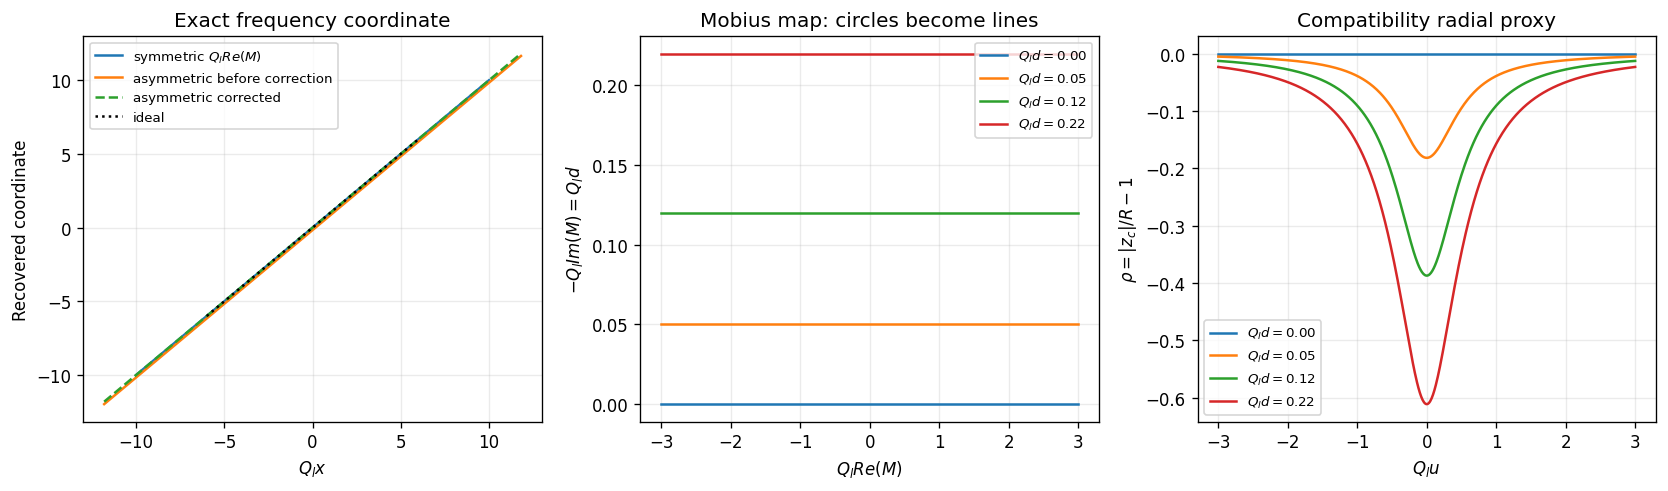

In [14]:
m_s = mobius_coordinate(cen_s, pc_s.radius, ql_s)
m_a = mobius_coordinate(cen_a, pc_a.radius, ql_a)
beta_a = np.imag(1.0 / coupling_q(QC, PHI_ASYM))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
axes[0].plot(x * ql_s, m_s.real * ql_s, label='symmetric $Q_l Re(M)$')
axes[0].plot(x * ql_a, m_a.real * ql_a, label='asymmetric before correction')
axes[0].plot(x * ql_a, (m_a.real - beta_a / 2.0) * ql_a, '--', label='asymmetric corrected')
axes[0].plot([-6, 6], [-6, 6], 'k:', label='ideal')
axes[0].set_title('Exact frequency coordinate')
axes[0].set_xlabel('$Q_l x$')
axes[0].set_ylabel('Recovered coordinate')
axes[0].legend()

u = np.linspace(-3.0, 3.0, 601) / ql_s
for qld in [0.0, 0.05, 0.12, 0.22]:
    d = qld / ql_s
    z_loss_centered = pc_s.radius * (
        1.0 - 2.0 * ql_s * d - 2j * ql_s * u
    ) / (
        1.0 + 2.0 * ql_s * d + 2j * ql_s * u
    )
    m = mobius_coordinate(z_loss_centered, pc_s.radius, ql_s)
    axes[1].plot(m.real * ql_s, -m.imag * ql_s, label=f'$Q_l d={qld:.2f}$')
    radial = np.abs(z_loss_centered) / pc_s.radius - 1.0
    axes[2].plot(u * ql_s, radial, label=f'$Q_l d={qld:.2f}$')
axes[1].set_title('Mobius map: circles become lines')
axes[1].set_xlabel('$Q_l Re(M)$')
axes[1].set_ylabel('$-Q_l Im(M)=Q_l d$')
axes[2].set_title('Compatibility radial proxy')
axes[2].set_xlabel('$Q_l u$')
axes[2].set_ylabel('$\\rho=|z_c|/R-1$')
axes[1].legend()
axes[2].legend()
savefig(fig, '05_mobius_linear_coordinates')
plt.show()


![Linear Mobius mapping](resonator_math/05_mobius_linear_coordinates.svg)

## 8. Duffing-nonlinear resonators

The nonlinear branch implemented by `fitting.s21_model()` uses

$$
\gamma=\frac{1}{Q_l}=\frac{1}{Q_i}+\operatorname{Re}\left(\frac{1}{Q_e}\right),
\qquad
y_0=\frac{x}{\gamma}=Q_lx.
$$

The driven coordinate $y$ is selected from the Duffing cubic

$$
4y^3-4y_0y^2+y-y_0-a_{\rm nl}=0,
$$

and the resonator-plane response is

$$
z=1-\frac{1/Q_e}{\gamma(1+2jy)}.
$$

After the same phase-centering transform,

$$
z_c=R\frac{1-2jy}{1+2jy}.
$$

The Mobius step therefore recovers the driven coordinate directly:

$$
M=\frac{y}{Q_l}=\gamma y.
$$

The cubic is linear in $y_0$, so the physical drive coordinate has a direct inverse:

$$
y_0=\frac{4y^3+y-a_{\rm nl}}{4y^2+1},
\qquad
x=\frac{y_0}{Q_l}.
$$

This inverse remains single-valued for a measured IQ point even where the forward sweep is bistable: the measured value of $y$ has already selected a branch.

### 8.1 Simultaneous nonlinear frequency and loss inversion

The same complex Mobius coordinate also recovers internal-loss motion. Let the calibration use $\gamma_0=1/Q_l$, and let a timestream sample have

$$
\gamma'=\gamma_0+\delta_i,
\qquad
\delta_i=\Delta\left(\frac{1}{Q_i}\right)=2q_d.
$$

Relative to the nominal phase-center geometry, the nonlinear centered response is

$$
z_c=R\left[\frac{2\gamma_0}{\gamma'(1+2jy)}-1\right].
$$

Substitution into the complex Mobius map gives

$$
M=\gamma'y-j\frac{\delta_i}{2}=\gamma'y-jq_d.
$$

Therefore

$$
q_d=-\operatorname{Im}(M),
\qquad
\gamma'=\gamma_0+2q_d,
\qquad
y=\frac{\operatorname{Re}(M)}{\gamma'},
$$

followed by

$$
x=\gamma'\frac{4y^3+y-a_{\rm nl}}{4y^2+1}.
$$

This is the default fitted `mobius` conversion implemented by `ResonatorCalibration`.

> **Codebase path: where nonlinearity enters.** `fitting.batch_fit(..., nonlinear=True)` may return a fitted `anl`. `ResonatorCalibration.from_fit()` stores that value, and `convert_raw_iq(..., method='mobius')` applies `physical_frequency_fraction()`, which calls `invert_duffing_coordinate()` when `anl != 0`. By contrast, `ResonatorCalibration.from_sweep()` estimates geometry directly from a sweep and has no fitted Duffing parameter, so its `mobius` frequency result remains the empirical circle coordinate. Use `from_fit()` when Duffing-aware inversion matters.

### 8.2 Onset of bifurcation

Writing $y_0$ as a function of $y$, a turnover occurs where

$$
\frac{dy_0}{dy}=0
\quad\Longleftrightarrow\quad
16y^4+8y^2+8a_{\rm nl}y+1=0.
$$

The first double root occurs at

$$
y=-\frac{1}{\sqrt{12}},
\qquad
a_{\rm nl,crit}=\frac{4}{3\sqrt{3}}\approx0.7698.
$$

The figures below include weak nonlinearity, the critical neighborhood, and clearly bifurcated cases.

> **Model caveat.** For nonzero mismatch angle $\phi$, the established nonlinear fit branch uses a real loaded-linewidth denominator. Its $a_{\rm nl}\rightarrow0$ limit is therefore not identical to the asymmetric linear branch. The analytic Duffing inverse here is exact for the nonlinear model currently implemented in `fitting.py`; changing that model convention is a separate migration.

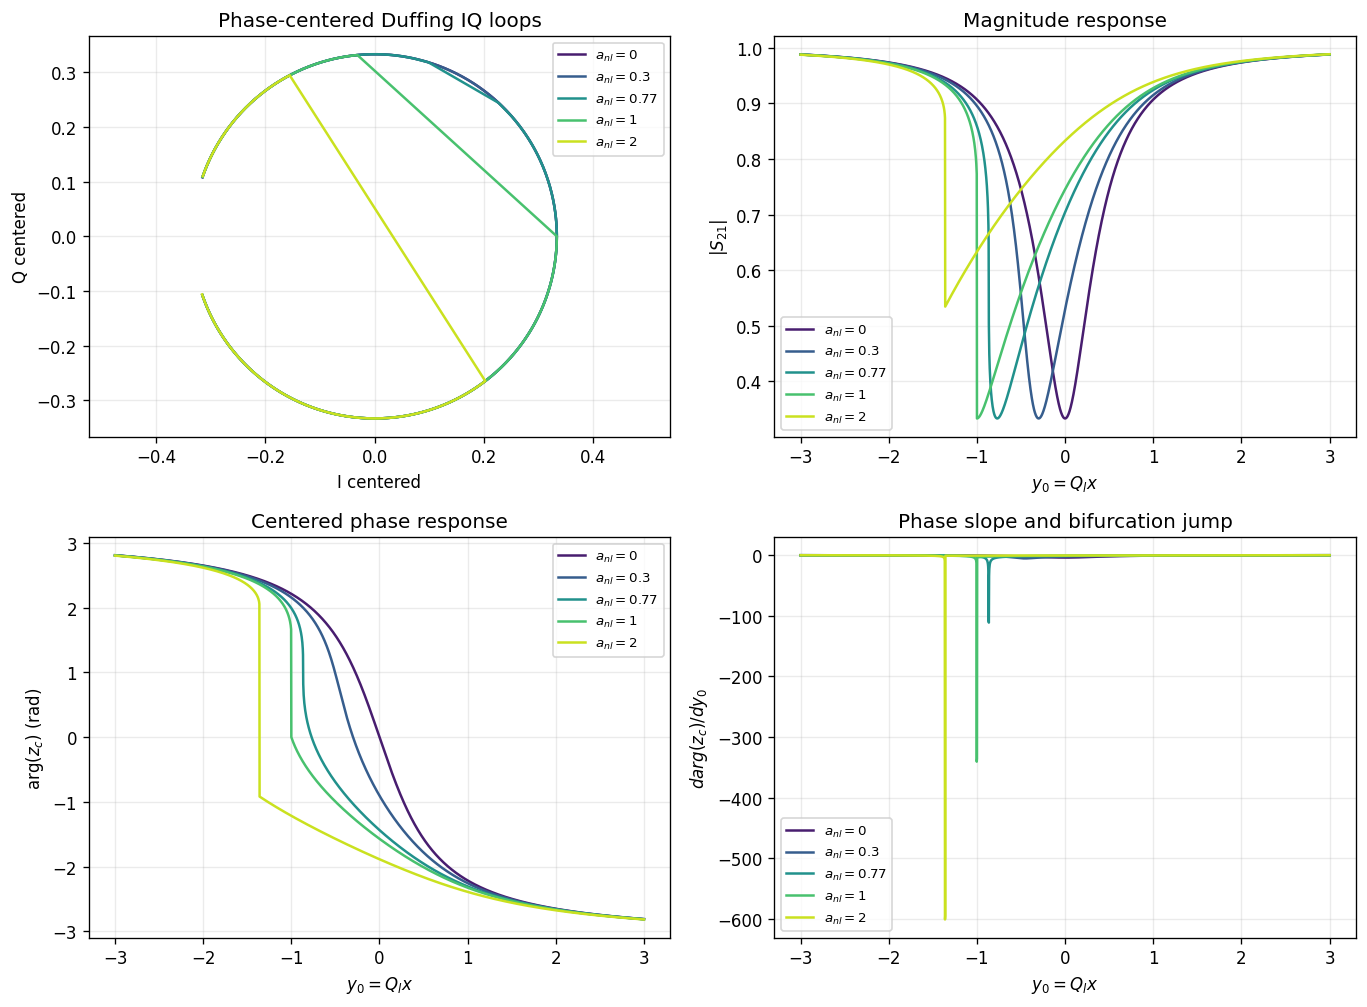

In [15]:
anl_values = [0.0, 0.3, 0.77, 1.0, 2.0]
colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(anl_values)))
y0 = np.linspace(-3.0, 3.0, 2401)
f_duffing = FR + y0 * FR / QL_SYM
pc_duffing = resonator.model_phase_center_geometry(QL_SYM, coupling_q(QC, 0.0))

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.5))
for anl, color in zip(anl_values, colors):
    z = fitting.s21_model(f_duffing, FR, QI, QC, 0.0, 1.0, 0.0, 0.0, anl=anl)
    zc = pc_duffing.apply(z)
    phase = np.unwrap(np.angle(zc))
    axes[0, 0].plot(zc.real, zc.imag, color=color, label=f'$a_{{nl}}={anl:g}$')
    axes[0, 1].plot(y0, np.abs(z), color=color, label=f'$a_{{nl}}={anl:g}$')
    axes[1, 0].plot(y0, phase, color=color, label=f'$a_{{nl}}={anl:g}$')
    axes[1, 1].plot(y0, np.gradient(phase, y0), color=color, label=f'$a_{{nl}}={anl:g}$')
axes[0, 0].set_title('Phase-centered Duffing IQ loops')
axes[0, 0].set_xlabel('I centered')
axes[0, 0].set_ylabel('Q centered')
axes[0, 0].set_aspect('equal', adjustable='datalim')
axes[0, 1].set_title('Magnitude response')
axes[0, 1].set_xlabel('$y_0=Q_l x$')
axes[0, 1].set_ylabel('$|S_{21}|$')
axes[1, 0].set_title('Centered phase response')
axes[1, 0].set_xlabel('$y_0=Q_l x$')
axes[1, 0].set_ylabel('arg($z_c$) (rad)')
axes[1, 1].set_title('Phase slope and bifurcation jump')
axes[1, 1].set_xlabel('$y_0=Q_l x$')
axes[1, 1].set_ylabel('$d arg(z_c) / dy_0$')
for ax in axes.ravel():
    ax.legend()
savefig(fig, '06_duffing_progression')
plt.show()


![Duffing progression](resonator_math/06_duffing_progression.svg)

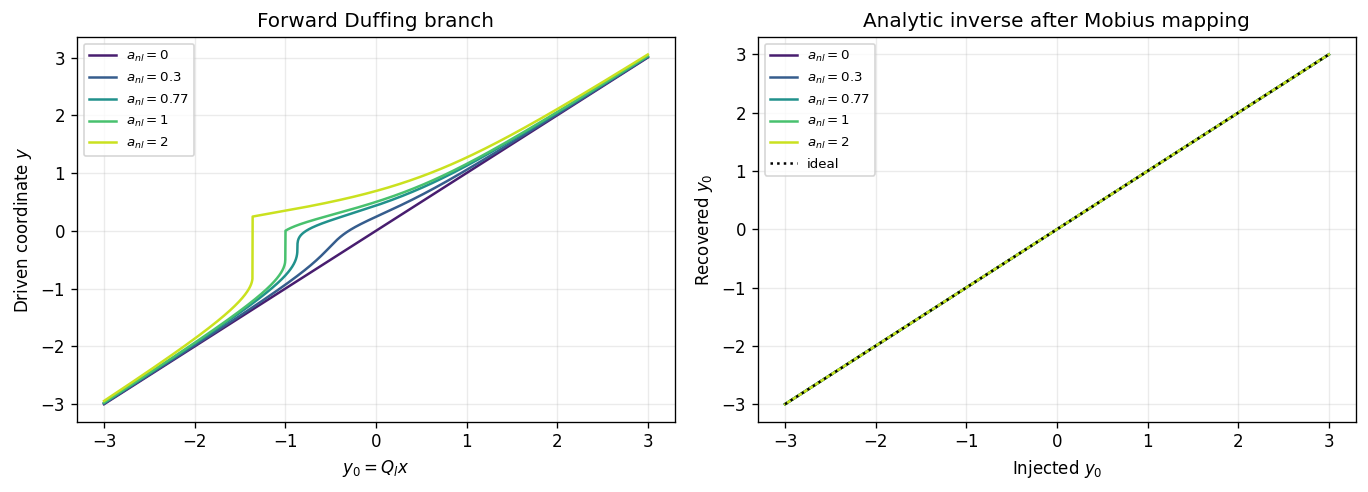

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for anl, color in zip(anl_values, colors):
    y = fitting.duffing_y(y0, anl)
    recovered_y0 = resonator.invert_duffing_coordinate(y, anl)
    axes[0].plot(y0, y, color=color, label=f'$a_{{nl}}={anl:g}$')
    axes[1].plot(y0, recovered_y0, color=color, label=f'$a_{{nl}}={anl:g}$')
axes[0].set_title('Forward Duffing branch')
axes[0].set_xlabel('$y_0=Q_l x$')
axes[0].set_ylabel('Driven coordinate $y$')
axes[1].set_title('Analytic inverse after Mobius mapping')
axes[1].set_xlabel('Injected $y_0$')
axes[1].set_ylabel('Recovered $y_0$')
axes[1].plot([-3, 3], [-3, 3], 'k:', label='ideal')
for ax in axes:
    ax.legend()
savefig(fig, '07_duffing_inverse')
plt.show()


![Duffing inverse](resonator_math/07_duffing_inverse.svg)

> **Codebase path: modulation.** Fast modulation uses the same calibration object differently from detector-noise analysis. `modulation.group_cycles()` reconstructs tagged modulation cycles. `modulation.demodulate(..., calibration=calibrations)` deembeds and phase-centers every deliberately applied probe point with its absolute frequency, then calls `convert_centered_iq()` and keeps the center point's absolute probe detuning. That is the useful control error for recentering and `needs_update`; no sweep-reference subtraction is applied.

## 9. Mapping the derivation onto the package API

| Operation | Canonical API | Mathematical action |
|---|---|---|
| parse hardware sweep payload | `client.parse_sweep_data()` | produce per-tone `sweep_f`, `sweep_i`, and `sweep_q` arrays |
| fit all parsed sweep tones | `fitting.batch_fit()` | preserve tone indices while fitting linear or Duffing models |
| empirical calibration | `ResonatorCalibration.from_sweep()` | estimate delay, edge baseline, circle geometry, $f_r$, and $Q_l$ directly from one sweep trace |
| fitted-model calibration | `ResonatorCalibration.from_fit()` | retain fitted envelope, exact model geometry, asymmetry origin correction, and optional Duffing parameter |
| scalar cable-delay removal | `remove_cable_delay()` | multiply by $e^{+j2\pi f\tau}$ |
| calibrated group-delay removal | `remove_group_delay()` | multiply by $e^{j2\pi\int\tau_gdf}$ |
| generic sweep deembedding | `deembed()` | delay removal, then divide by edge baseline |
| fitted-model deembedding | `model_deembed()` | multiply by $E(f)^{-1}$ |
| phase centering | `phase_center()` | fit circle, subtract center, rotate baseline to negative real axis |
| exact fitted circle geometry | `model_phase_center_geometry()` | compute $C$, $R$, and $\theta$ from $Q_l,Q_e$ |
| local conversion | `linearized_frequency_and_dissipation()` | project onto sweep tangent and normal |
| absolute fitted conversion | `ResonatorCalibration.convert_raw_iq()` | deembed, phase-center, Mobius-invert, then Duffing-invert if needed |
| fixed-tone referenced conversion | `ResonatorCalibration.convert_referenced_raw_iq()` | subtract reference IQ and report detector motion with the historical sign |
| fixed-tone optimized conversion | `ResonatorCalibration.tone_converter()` | precombine fixed-tone complex multiplies |
| multi-tone detector-noise conversion | `noise.fractional_frequency_and_dissipation_timestreams()` | select local, fitted, or diagnostic conversion and return sweep-referenced timestream rows |
| modulation-cycle conversion | `modulation.demodulate()` | retain absolute center-probe detuning for recentering and tracking |

### 9.1 Constructing calibrations from a real parsed sweep

A fit-derived calibration is the complete path: it can preserve asymmetric-model geometry and carry a fitted Duffing parameter into conversion.

```python
from souk_readout_tools import fitting, resonator

sweep = client.parse_sweep_data(client.get_sweep_data())
fits = fitting.batch_fit(sweep, nonlinear=True, try_harder=True, n_jobs=-1)
calibrations = {
    fit.tone_index: resonator.ResonatorCalibration.from_fit(fit)
    for fit in fits if fit.success
}
```

For a model-light comparison, construct an empirical calibration directly from one parsed sweep trace. This estimates the circle geometry but does not infer a Duffing parameter.

```python
tone_index = 0
sweep_f = sweep['sweep_f'][:, tone_index]
sweep_z = sweep['sweep_i'][:, tone_index] + 1j * sweep['sweep_q'][:, tone_index]
cal = resonator.ResonatorCalibration.from_sweep(sweep_f, sweep_z)
```

### 9.2 Low-level absolute fitted conversion

A fitted fixed-tone conversion is intentionally explicit about the probe frequency:

```python
cal = resonator.ResonatorCalibration.from_fit(fit)
df_hz, delta_inverse_2Qi = cal.convert_raw_iq(tone_frequency, z_timestream)
delta_inverse_Qi = 2 * delta_inverse_2Qi

# Probe-side diagnostic circle coordinate and raw radial proxy:
df_circle_hz, radial_loss_proxy = cal.convert_raw_iq(
    tone_frequency, z_timestream, method='circle')
```

For publication-quality physical internal-loss analysis in the linear model, retain the full complex Mobius coordinate. The matched-scale quadrature is `delta_inverse_2Qi`; double it for the commonly reported physical `Delta(1/Qi)` quantity:

```python
z_centered = cal.transform_raw_iq(tone_frequency, z_timestream)
M = -1j * (cal.radius - z_centered) / (2 * cal.Ql * (cal.radius + z_centered))
fractional_probe_detuning = M.real - cal.frequency_origin_fraction
delta_inverse_2Qi = -M.imag
delta_inverse_Qi = 2 * delta_inverse_2Qi
```

For fixed-tone detector motion, negate changes in probe detuning relative to a baseline. `cal.convert_referenced_raw_iq(tone_frequency, z_timestream, reference_z)` applies that convention directly.

### 9.3 High-level detector-noise conversion

For parsed samples, the multi-tone noise helper performs that reference interpolation and sign conversion per tone. It is the convenient entry point for side-by-side noise plots:

```python
from souk_readout_tools.noise import fractional_frequency_and_dissipation_timestreams

linear = fractional_frequency_and_dissipation_timestreams(
    samples, sweep, tones=[tone_index], method='linearized')
mobius = fractional_frequency_and_dissipation_timestreams(
    samples, sweep, tones=[tone_index], method='mobius', calibrations=calibrations)
circle = fractional_frequency_and_dissipation_timestreams(
    samples, sweep, tones=[tone_index], method='circle', calibrations=calibrations)
```

`linear['frequency']` and `mobius['frequency']` are directly comparable sweep-referenced resonator-motion timestreams. `circle['dissipation']` is the reference-subtracted radial diagnostic $\Delta\rho$, so keep it on a separately labelled axis.

The plotting layer delegates to the same noise helper. For an immediate visual check, use `plot_timestream(..., format='freq_diss', conversion_method='mobius', calibrations=calibrations)` or the corresponding `plot_timestream_psd()` call. Selecting `conversion_method='circle'` changes the lower-axis label to the radial proxy change so it is not mistaken for matched dissipation.

## 10. Summary

1. A notch resonance is a circle in complex transmission once the readout-chain envelope is removed.
2. Phase centering is an affine transform: subtract the circle center and rotate its reference axis.
3. Magnitude and phase are ordinary polar coordinates, but their interpretation depends on the chosen IQ origin.
4. The historical frequency/dissipation converter is a local tangent/normal projection. It is useful near one operating point and its second quadrature linearizes to the matched-scale coordinate $q_d=\Delta(1/2Q_i)$.
5. The complex Mobius transform exactly unwraps the symmetric linear circle into frequency and physical internal-loss coordinates.
6. A complex coupling quality factor shifts the Mobius frequency origin by $\operatorname{Im}(1/Q_e)/2$; correcting that constant makes the asymmetric linear inversion exact.
7. For the implemented Duffing model, Mobius inversion first recovers the driven coordinate $y$, and a direct algebraic inverse recovers probe detuning $x=(f_{\rm probe}-f_r)/f_r$ even on a selected bistable branch.
8. Device loss is commonly reported as $\Delta(1/Q_i)=2q_d$. The factor-of-two half scaling is useful when overplotting frequency and dissipation noise because it puts the two local IQ quadratures on comparable axes.
9. The default fitted `mobius` API returns the matched $q_d$ coordinate. The diagnostic `circle` path returns the radial proxy $\rho=|z_c|/R-1$ instead. Normalize $\rho$ around a stated operating point before comparing it directly with fractional-frequency spectra.